In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import scienceplots

plt.style.use('science')

import numpy as np
from scipy.optimize import bisect

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

from pycbc.psd.analytical import aLIGO140MpcT1800545, aLIGO175MpcT1800545
from pycbc.filter import sigma, sigmasq
from pycbc.types import TimeSeries, FrequencySeries

PyCBC.libutils: pkg-config call failed, setting NO_PKGCONFIG=1


In [2]:
import sys
import os

sys.path.insert(1, '../../detectability')

import resonance
from resonance import Filter, phase_diff_t_shift, phase_shift #System, 

In [3]:
data_phi_path = '../data/III/dL/phi'
os.makedirs(data_phi_path, exist_ok=True) 

data_t_path = '../data/III/dL/t'
os.makedirs(data_t_path, exist_ok=True) 

# Plots article

In [4]:
detector_name = {aLIGO175MpcT1800545: 'O4', 'aLIGO/AplusDesign': 'Aplus', 'aLIGO/Asharp_strain': 'Asharp', 'ET/ET_B': 'ET', 'CE/CE_40': 'CE'} 

In [5]:
def article_plot_ab(dPsi):
    if dPsi == phase_shift:
        x = 'phi'
    elif dPsi == phase_diff_t_shift:
        x = 't'

    plt.figure(figsize=(3.5, 2.5), constrained_layout=True)

    detector='aLIGO/AplusDesign'
    color='k'
    data = np.load(os.path.join(f'../data/III/dL/{x}', f'{x}_{detector_name[detector]}.npz'))
           
    fres_arr = data['fres']
    dx_arr = -data['detect']
    dx_guess_arr = -data['guess']
    joc_arr = -data['joc']
    dx_cut_arr = -data['cut']

    plt.loglog(fres_arr, dx_guess_arr,  '--', color = color, label=f'Quadratic')
    plt.loglog(fres_arr, dx_arr, '-', color = color, alpha=0.5,label=f'Numerical')
    #plt.loglog(fres_arr, dx_cut_arr, color = color, alpha=0.5, label=f'Cut. {detector_name[detector]}')

    joc=FrequencySeries(joc_arr, delta_f=1.)
    
    if dPsi == phase_shift:
        plt.loglog(fres_arr, joc_arr, '-.', color = color, label=f'Single-Frequency') #Detectability lower bound
        plt.title(f'(b)')
        plt.ylabel('Phase shift [rad]')
        plt.ylim(2e-3,5)

    elif dPsi == phase_diff_t_shift:
        plt.loglog(fres_arr, joc_arr/(2*np.pi*fres_arr), '-.', color = color, label=f'Single-Frequency') #Detectability lower bound
        plt.title(f'(a)')
        plt.ylabel('Time shift [s]') 
            
    plt.xlabel('Resonant Frequency [Hz]')
    plt.legend()
        

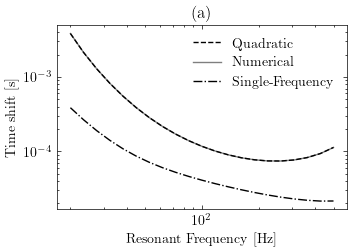

In [6]:
article_plot_ab(phase_diff_t_shift) 

plt.savefig(os.path.join(f'../figures/III/dL', f'III_a.png'), bbox_inches='tight', dpi=300)

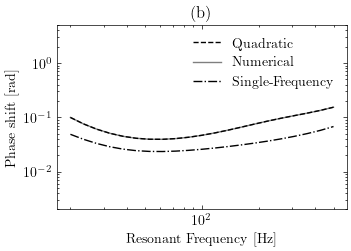

In [7]:
article_plot_ab(phase_shift) 

plt.savefig(os.path.join(f'../figures/III/dL', f'III_b.png'), bbox_inches='tight', dpi=300)

In [8]:
def article_plot_c(dx_detector):
    plt.figure(figsize=(3.5, 2.5), constrained_layout=True)
    for detector, line_type in dx_detector:
        data = np.load(os.path.join(f'../data/III/dL/t', f't_{detector_name[detector]}.npz'))
                  
        fres_arr = data['fres']
        dx_arr_guess = -data['detect']

        plt.loglog(fres_arr, dx_arr_guess, line_type,label=f'{detector_name[detector]}')        
        #plt.title(f'(c)')
        plt.ylabel('Time shift [s]') 
        plt.xlabel('Resonant Frequency [Hz]')
        plt.legend()

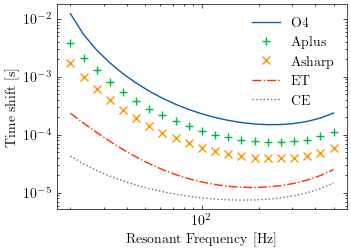

In [9]:
dx_detector = [[aLIGO175MpcT1800545, '-'],['aLIGO/AplusDesign', '+'], ['aLIGO/Asharp_strain', 'x'], ['ET/ET_B', '-.'], ['CE/CE_40', ':']]
article_plot_c(dx_detector) 
plt.savefig(os.path.join(f'../figures/III/dL', f'III_c.png'), bbox_inches='tight', dpi=300)